# 🫁 Chest X-Ray Pneumonia Detection — Deep Learning (CNN)

**Architecture:** Custom CNN + Transfer Learning (VGG16)

**Output files:** `pneumonia_cnn_model.h5`, `dl_scaler.pkl` (label info)

---
### Dataset Structure Expected:
```
chest_xray/
  train/
    NORMAL/
    PNEUMONIA/
  test/
    NORMAL/
    PNEUMONIA/
```

In [1]:
# =============================================================
# CELL 1 — INSTALL DEPENDENCIES
# =============================================================
%pip install tensorflow keras scikit-learn matplotlib seaborn numpy pillow

   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.6 MB 3.9 MB/s eta 0:01:31
   ---------------------------------------- 1.8/350.6 MB 3.9 MB/s eta 0:01:31
   ---------------------------------------- 2.6/350.6 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 3.4/350.6 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 4.2/350.6 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 5.0/350.6 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 5.8/350.6 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 6.6/350.6 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 7.3/350.6 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 7.6/350.6 MB 3.9 MB/s eta 0:01:28
   - -------------------------------------- 8.9/350.6 MB 3.8 MB/s eta 0:01:30


In [2]:
# =============================================================
# CELL 2 — IMPORTS
# =============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU available: False


In [ ]:
# =============================================================
# CELL 3 — CONFIGURATION  (no val folder version)
# =============================================================
import os

BASE_DIR  = 'chest_xray'   
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = None           
# ── Confirm folders exist ─────────────────────────────────────
for name, path in [('TRAIN', TRAIN_DIR), ('TEST', TEST_DIR)]:
    if not os.path.isdir(path):
        raise FileNotFoundError(f"{name} folder not found: {path}")
    print(f"✅ {name}: {path}  →  {os.listdir(path)}")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4

print(f"\nIMG_SIZE   : {IMG_SIZE}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"EPOCHS     : {EPOCHS}")

✅ TRAIN: chest_xray\train  →  ['NORMAL', 'PNEUMONIA']
✅ TEST: chest_xray\test  →  ['NORMAL', 'PNEUMONIA']

IMG_SIZE   : (224, 224)
BATCH_SIZE : 32
EPOCHS     : 20


In [4]:
# =============================================================
# CELL 4 — EXPLORE DATASET
# =============================================================

for split in ['train', 'val', 'test']:
    split_path = os.path.join(BASE_DIR, split)
    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path)) if os.path.exists(cls_path) else 0
        print(f'{split:6s} | {cls:9s} | {count:5d} images')
    print()

train  | NORMAL    |     0 images
train  | PNEUMONIA |     0 images

val    | NORMAL    |     0 images
val    | PNEUMONIA |     0 images

test   | NORMAL    |     0 images
test   | PNEUMONIA |     0 images



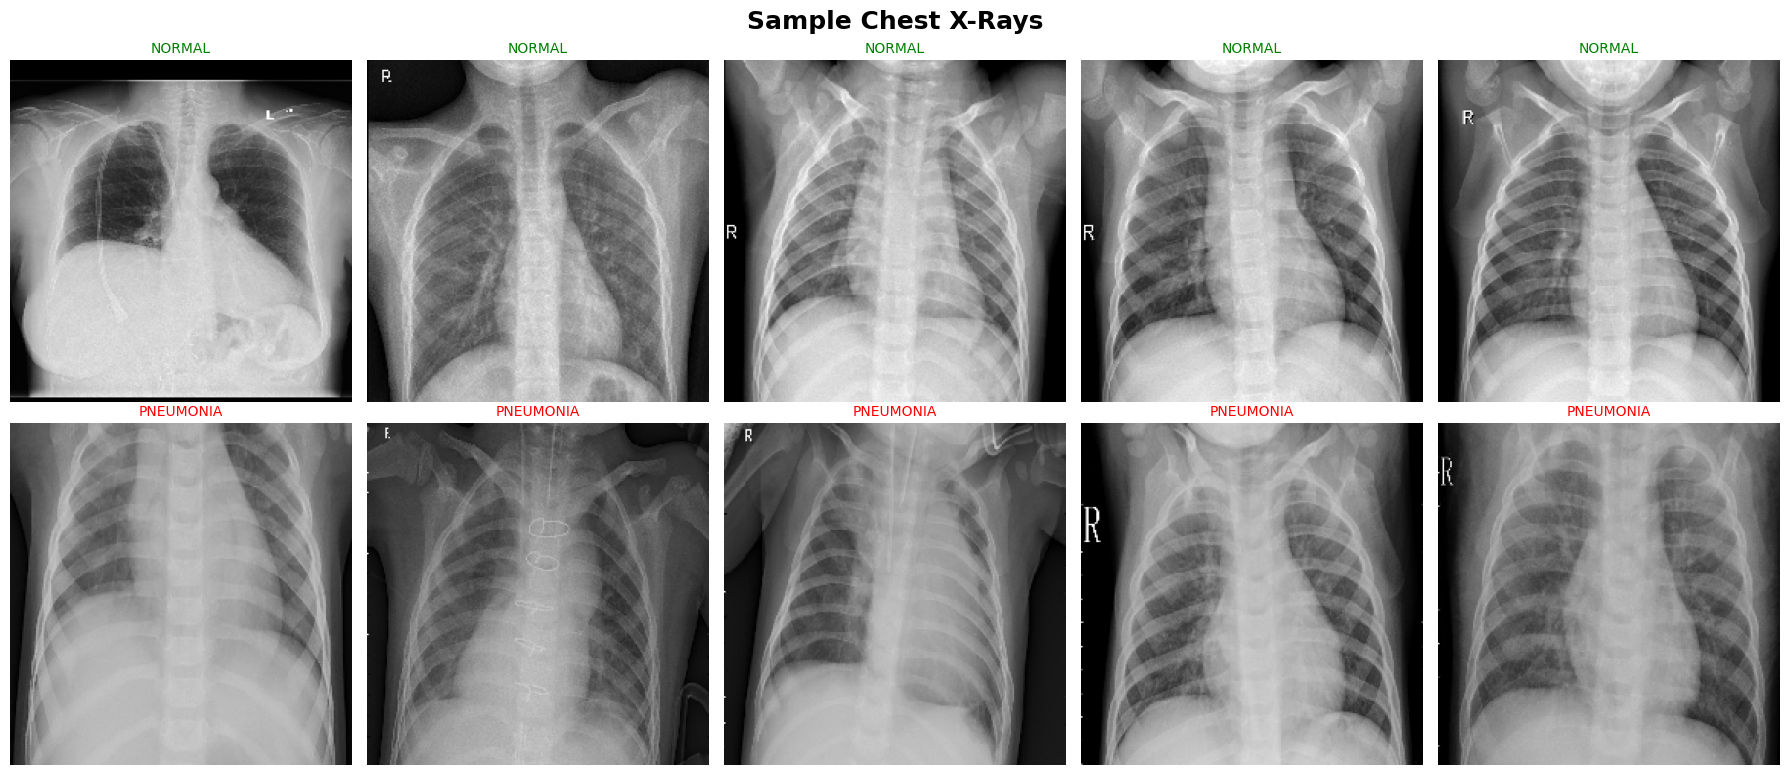

In [7]:
# =============================================================
# CELL 5 — VISUALISE SAMPLE IMAGES
# =============================================================

from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Chest X-Rays', fontsize=18, fontweight='bold')

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)

    # ── Filter out hidden files / non-images ──────────────────
    valid_exts = ('.jpg', '.jpeg', '.png')
    files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(valid_exts)
    ][:5]

    for j, fname in enumerate(files):
        img = load_img(os.path.join(cls_path, fname), target_size=IMG_SIZE)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(
            cls,
            fontsize=10,
            color='green' if 'normal' in cls.lower() else 'red'  # ← fixed
        )
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('sample_xrays.png', dpi=120)
plt.show()

In [14]:
# =============================================================
# CELL 6 — GENERATORS  (train/test only, val split from train)
# =============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Training datagen: augmentation + 20% validation split ────
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2        # splits 80% train / 20% val internally
)

# ── Test datagen: only rescale, no augmentation ───────────────
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ── Train generator (80% of train folder) ────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

# ── Val generator (20% of train folder) ──────────────────────
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

# ── Test generator (test folder) ─────────────────────────────
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# ── Summary ──────────────────────────────────────────────────
CLASSES = list(train_gen.class_indices.keys())

print(f"Train samples : {train_gen.samples}")
print(f"Val   samples : {val_gen.samples}")
print(f"Test  samples : {test_gen.samples}")
print(f"Class indices : {train_gen.class_indices}")
print(f"Classes       : {CLASSES}")

if train_gen.samples == 0:
    raise ValueError(
        f"No images found!\n"
        f"Contents of {TRAIN_DIR}: {os.listdir(TRAIN_DIR)}"
    )

Found 2305 images belonging to 2 classes.
Found 576 images belonging to 2 classes.
Found 721 images belonging to 2 classes.
Train samples : 2305
Val   samples : 576
Test  samples : 721
Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}
Classes       : ['NORMAL', 'PNEUMONIA']


In [15]:
# =============================================================
# CELL 7 — BUILD CNN MODEL (Transfer Learning — VGG16)
# =============================================================

# Load VGG16 pretrained on ImageNet, without the top classifier
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze base layers (feature extraction only)
base_model.trainable = False

# Build the full model
model = models.Sequential([
    base_model,

    # ── Custom head ──────────────────────────────────────
    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Binary output: NORMAL (0) vs PNEUMONIA (1)
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,144,769 (57.77 MB)

 Trainable params: 428,545 (1.63 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [16]:
# =============================================================
# CELL 8 — CALLBACKS
# =============================================================

callbacks = [
    # Stop early if val_loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model checkpoint
    ModelCheckpoint(
        'pneumonia_cnn_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Reduce LR when plateau detected
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('Callbacks ready.')

Callbacks ready.


In [17]:
# =============================================================
# CELL 9 — TRAIN PHASE 1 (Frozen base)
# =============================================================

print('=== PHASE 1: Training custom head (base frozen) ===')

history1 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print('\nPhase 1 complete.')

=== PHASE 1: Training custom head (base frozen) ===
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6434 - auc: 0.6810 - loss: 0.7408 - precision: 0.6787 - recall: 0.4894
Epoch 1: val_auc improved from None to 0.93592, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.7531 - auc: 0.8234 - loss: 0.5593 - precision: 0.8228 - recall: 0.6450 - val_accuracy: 0.8455 - val_auc: 0.9359 - val_loss: 0.6211 - val_precision: 0.8024 - val_recall: 0.9167 - learning_rate: 1.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8495 - auc: 0.9176 - loss: 0.3722 - precision: 0.8681 - recall: 0.8099
Epoch 2: val_auc improved from 0.93592 to 0.93725, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.8664 - auc: 0.9294 - loss: 0.3445 - precision: 0.9027 - recall: 0.8212 - val_accuracy: 0.8663 - val_auc: 0.9372 - val_loss: 0.5696 - val_precision: 0.8094 - val_recall: 0.9583 - learning_rate: 1.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8934 - auc: 0.9419 - loss: 0.3099 - precision: 0.9187 - recall: 0.8654
Epoch 3: val_auc improved from 0.93725 to 0.95360, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.8850 - auc: 0.9385 - loss: 0.3195 - precision: 0.9065 - recall: 0.8585 - val_accuracy: 0.8854 - val_auc: 0.9536 - val_loss: 0.4979 - val_precision: 0.8513 - val_recall: 0.9340 - learning_rate: 1.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8814 - auc: 0.9413 - loss: 0.3141 - precision: 0.8953 - recall: 0.8638
Epoch 4: val_auc improved from 0.95360 to 0.96024, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.8876 - auc: 0.9444 - loss: 0.3050 - precision: 0.8997 - recall: 0.8724 - val_accuracy: 0.8976 - val_auc: 0.9602 - val_loss: 0.4316 - val_precision: 0.8804 - val_recall: 0.9201 - learning_rate: 1.0000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8990 - auc: 0.9520 - loss: 0.2762 - precision: 0.9178 - recall: 0.8782
Epoch 5: val_auc improved from 0.96024 to 0.96865, saving model to pneumonia_cnn_model.h5


...

73/73 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.9093 - auc: 0.9655 - loss: 0.2377 - precision: 0.9104 - recall: 0.9080 - val_accuracy: 0.9115 - val_auc: 0.9768 - val_loss: 0.2151 - val_precision: 0.9575 - val_recall: 0.8611 - learning_rate: 1.0000e-04
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9079 - auc: 0.9612 - loss: 0.2558 - precision: 0.9058 - recall: 0.9077
Epoch 10: val_auc improved from 0.97682 to 0.97927, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9124 - auc: 0.9642 - loss: 0.2438 - precision: 0.9152 - recall: 0.9089 - val_accuracy: 0.9167 - val_auc: 0.9793 - val_loss: 0.1992 - val_precision: 0.9580 - val_recall: 0.8715 - learning_rate: 1.0000e-04
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9109 - auc: 0.9669 - loss: 0.2393 - precision: 0.9013 - recall: 0.9137
Epoch 11: val_auc improved from 0.97927 to 0.98320, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9093 - auc: 0.9649 - loss: 0.2412 - precision: 0.9154 - recall: 0.9019 - val_accuracy: 0.9167 - val_auc: 0.9832 - val_loss: 0.1882 - val_precision: 0.9651 - val_recall: 0.8646 - learning_rate: 1.0000e-04
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9137 - auc: 0.9697 - loss: 0.2237 - precision: 0.9136 - recall: 0.9126
Epoch 12: val_auc improved from 0.98320 to 0.98321, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9171 - auc: 0.9691 - loss: 0.2239 - precision: 0.9241 - recall: 0.9089 - val_accuracy: 0.9358 - val_auc: 0.9832 - val_loss: 0.1665 - val_precision: 0.9435 - val_recall: 0.9271 - learning_rate: 1.0000e-04
Epoch 13/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9165 - auc: 0.9723 - loss: 0.2126 - precision: 0.9302 - recall: 0.9045
Epoch 13: val_auc did not improve from 0.98321
73/73 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9228 - auc: 0.9731 - loss: 0.2097 - precision: 0.9272 - recall: 0.9175 - val_accuracy: 0.9236 - val_auc: 0.9830 - val_loss: 0.1737 - val_precision: 0.9420 - val_recall: 0.9028 - learning_rate: 1.0000e-04
Epoch 14/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9130 - auc: 0.9671 - loss: 0.2382 - precision: 0.9203 - recall: 0.8971
Epoch 14: val_auc did not improve from 0.98321
73/73 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9163 - auc: 0.9678 - loss: 0.2293 - precision: 0.9316 - recall: 0.


Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
73/73 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.9223 - auc: 0.9741 - loss: 0.2031 - precision: 0.9241 - recall: 0.9201 - val_accuracy: 0.9306 - val_auc: 0.9862 - val_loss: 0.1840 - val_precision: 0.9769 - val_recall: 0.8819 - learning_rate: 1.0000e-04
Epoch 16/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9269 - auc: 0.9737 - loss: 0.2094 - precision: 0.9410 - recall: 0.9162
Epoch 16: val_auc did not improve from 0.98618
73/73 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9254 - auc: 0.9716 - loss: 0.2125 - precision: 0.9313 - recall: 0.9184 - val_accuracy: 0.9288 - val_auc: 0.9841 - val_loss: 0.1727 - val_precision: 0.9660 - val_recall: 0.8889 - learning_rate: 5.0000e-05
Epoch 17/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9315 - auc: 0.9776 - loss: 0.1871 - precision: 0.9271 - recall: 0.9314
Epoch 17: val_auc did not improve from 0.98618
73/73 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - 

In [18]:
# =============================================================
# CELL 10 — FINE-TUNING PHASE 2 (Unfreeze last 4 VGG16 layers)
# =============================================================

print('=== PHASE 2: Fine-tuning (unfreeze last VGG16 block) ===')

# Unfreeze last block of VGG16 (block5_conv1, block5_conv2, block5_conv3)
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Re-compile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR / 10),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print('\nPhase 2 complete. Best model saved to pneumonia_cnn_model.h5')

=== PHASE 2: Fine-tuning (unfreeze last VGG16 block) ===
Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9192 - auc: 0.9746 - loss: 0.2042 - precision: 0.9191 - recall: 0.9182
Epoch 1: val_auc did not improve from 0.98618
73/73 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9254 - auc: 0.9746 - loss: 0.2017 - precision: 0.9283 - recall: 0.9219 - val_accuracy: 0.9288 - val_auc: 0.9855 - val_loss: 0.1848 - val_precision: 0.9732 - val_recall: 0.8819 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9316 - auc: 0.9780 - loss: 0.1870 - precision: 0.9376 - recall: 0.9221
Epoch 2: val_auc improved from 0.98618 to 0.98692, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9262 - auc: 0.9769 - loss: 0.1933 - precision: 0.9376 - recall: 0.9132 - val_accuracy: 0.9479 - val_auc: 0.9869 - val_loss: 0.1347 - val_precision: 0.9542 - val_recall: 0.9410 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9416 - auc: 0.9829 - loss: 0.1626 - precision: 0.9527 - recall: 0.9274
Epoch 3: val_auc improved from 0.98692 to 0.99128, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9380 - auc: 0.9817 - loss: 0.1690 - precision: 0.9492 - recall: 0.9253 - val_accuracy: 0.9583 - val_auc: 0.9913 - val_loss: 0.1188 - val_precision: 0.9714 - val_recall: 0.9444 - learning_rate: 1.0000e-05
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9387 - auc: 0.9851 - loss: 0.1532 - precision: 0.9375 - recall: 0.9396
Epoch 4: val_auc did not improve from 0.99128
73/73 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9384 - auc: 0.9841 - loss: 0.1572 - precision: 0.9414 - recall: 0.9349 - val_accuracy: 0.9497 - val_auc: 0.9901 - val_loss: 0.1482 - val_precision: 0.9887 - val_recall: 0.9097 - learning_rate: 1.0000e-05
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9438 - auc: 0.9839 - loss: 0.1616 - precision: 0.9401 - recall: 0.9480
Epoch 5: val_auc improved from 0.99128 to 0.99503, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.9440 - auc: 0.9858 - loss: 0.1501 - precision: 0.9483 - recall: 0.9392 - val_accuracy: 0.9427 - val_auc: 0.9950 - val_loss: 0.1334 - val_precision: 0.9885 - val_recall: 0.8958 - learning_rate: 1.0000e-05
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9553 - auc: 0.9872 - loss: 0.1387 - precision: 0.9613 - recall: 0.9487
Epoch 6: val_auc did not improve from 0.99503

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
73/73 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9488 - auc: 0.9868 - loss: 0.1419 - precision: 0.9551 - recall: 0.9418 - val_accuracy: 0.9427 - val_auc: 0.9895 - val_loss: 0.1630 - val_precision: 0.9961 - val_recall: 0.8889 - learning_rate: 1.0000e-05
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9495 - auc: 0.9904 - loss: 0.1244 - precision: 0.9547 - recall: 0.9433
Epoch 7: val_auc improved from 0.99503 to 0.99634, saving model to pneumonia_cnn_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9523 - auc: 0.9904 - loss: 0.1244 - precision: 0.9586 - recall: 0.9453 - val_accuracy: 0.9774 - val_auc: 0.9963 - val_loss: 0.0792 - val_precision: 0.9725 - val_recall: 0.9826 - learning_rate: 5.0000e-06
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9561 - auc: 0.9889 - loss: 0.1293 - precision: 0.9623 - recall: 0.9490
Epoch 8: val_auc did not improve from 0.99634
73/73 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.9505 - auc: 0.9878 - loss: 0.1353 - precision: 0.9585 - recall: 0.9418 - val_accuracy: 0.9635 - val_auc: 0.9963 - val_loss: 0.1047 - val_precision: 0.9435 - val_recall: 0.9861 - learning_rate: 5.0000e-06
Epoch 9/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9536 - auc: 0.9902 - loss: 0.1228 - precision: 0.9488 - recall: 0.9585
Epoch 9: val_auc did not improve from 0.99634
73/73 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.9588 - auc: 0.9902 - loss: 0.1200 - precision: 0.9600 - recall: 0.9575

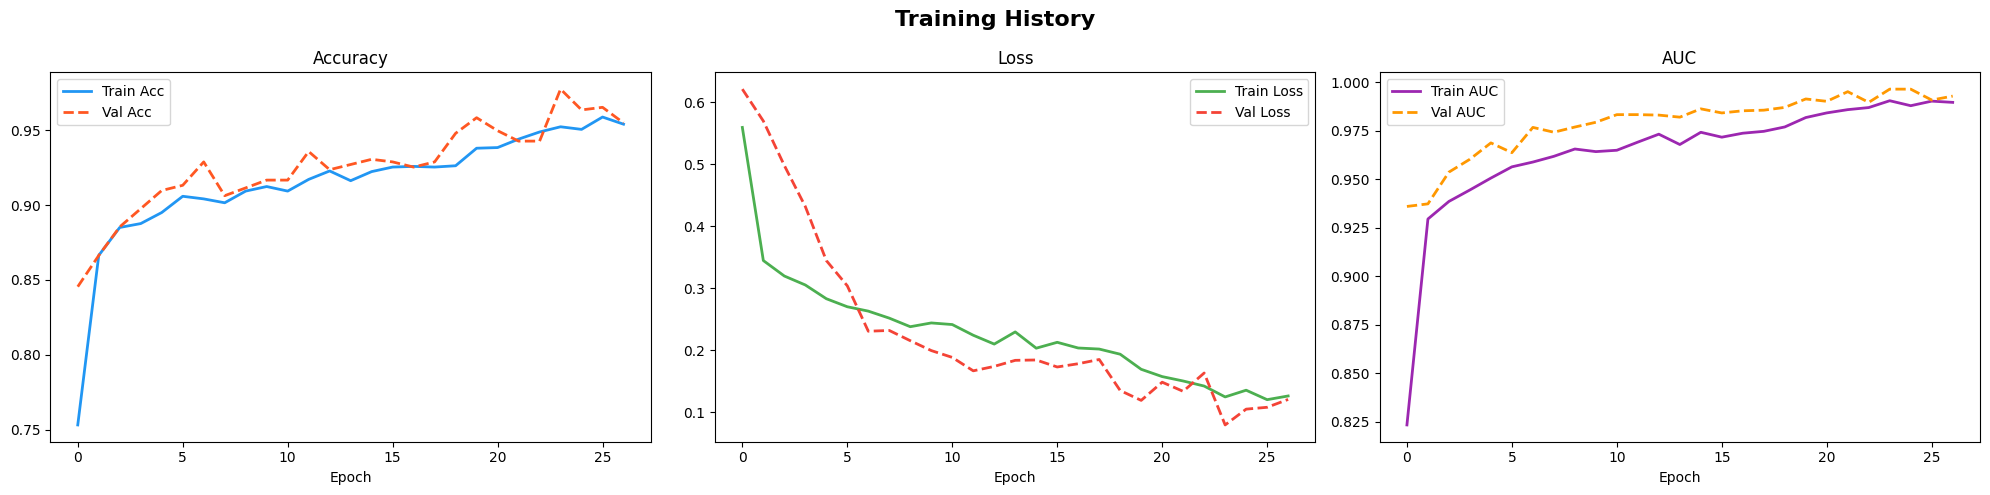

In [19]:
# =============================================================
# CELL 11 — PLOT TRAINING HISTORY
# =============================================================

def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_history(history1, history2)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Accuracy
axes[0].plot(hist['accuracy'],     label='Train Acc', color='#2196F3', lw=2)
axes[0].plot(hist['val_accuracy'], label='Val Acc',   color='#FF5722', lw=2, ls='--')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')

# Loss
axes[1].plot(hist['loss'],     label='Train Loss', color='#4CAF50', lw=2)
axes[1].plot(hist['val_loss'], label='Val Loss',   color='#F44336', lw=2, ls='--')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

# AUC
axes[2].plot(hist['auc'],     label='Train AUC', color='#9C27B0', lw=2)
axes[2].plot(hist['val_auc'], label='Val AUC',   color='#FF9800', lw=2, ls='--')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_history.png', dpi=120)
plt.show()

In [20]:
# =============================================================
# CELL 12 — EVALUATE ON TEST SET
# =============================================================

# Load best model
best_model = keras.models.load_model('pneumonia_cnn_model.h5')

test_gen.reset()
results = best_model.evaluate(test_gen, verbose=1)

print('\n========= TEST RESULTS =========')
for name, val in zip(best_model.metrics_names, results):
    print(f'{name:12s}: {val:.4f}')

721/721 ━━━━━━━━━━━━━━━━━━━━ 51s 69ms/step - accuracy: 0.9515 - auc: 0.9941 - loss: 0.1416 - precision: 1.0000 - recall: 0.9028

========= TEST RESULTS =========
loss        : 0.1416
compile_metrics: 0.9515


721/721 ━━━━━━━━━━━━━━━━━━━━ 50s 69ms/step


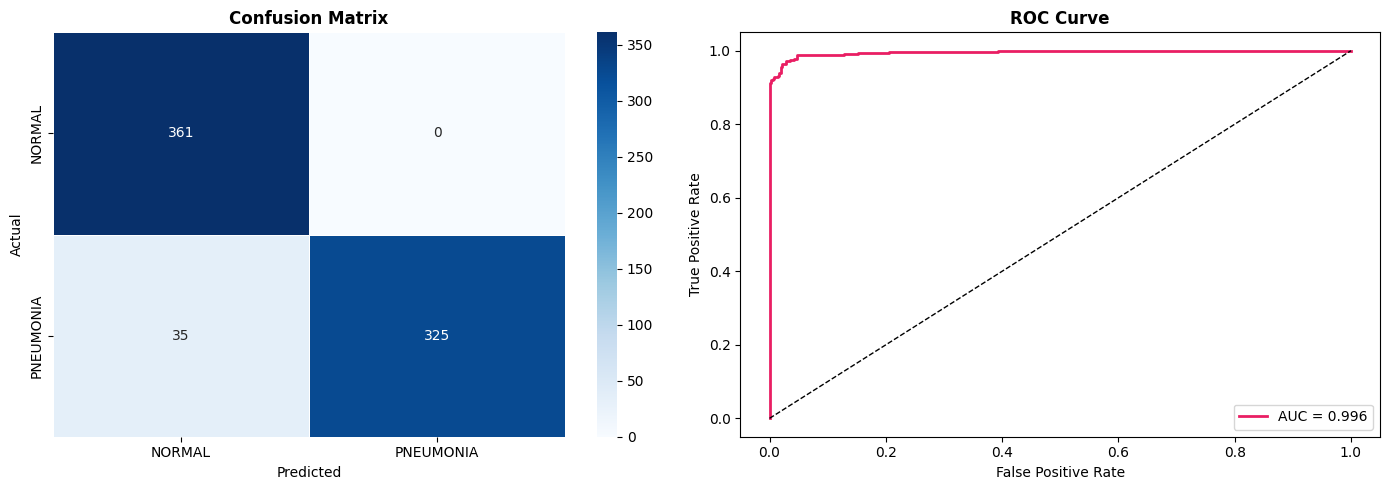


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      1.00      0.95       361
   PNEUMONIA       1.00      0.90      0.95       360

    accuracy                           0.95       721
   macro avg       0.96      0.95      0.95       721
weighted avg       0.96      0.95      0.95       721



In [21]:
# =============================================================
# CELL 13 — CONFUSION MATRIX & CLASSIFICATION REPORT
# =============================================================

test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#E91E63', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=120)
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

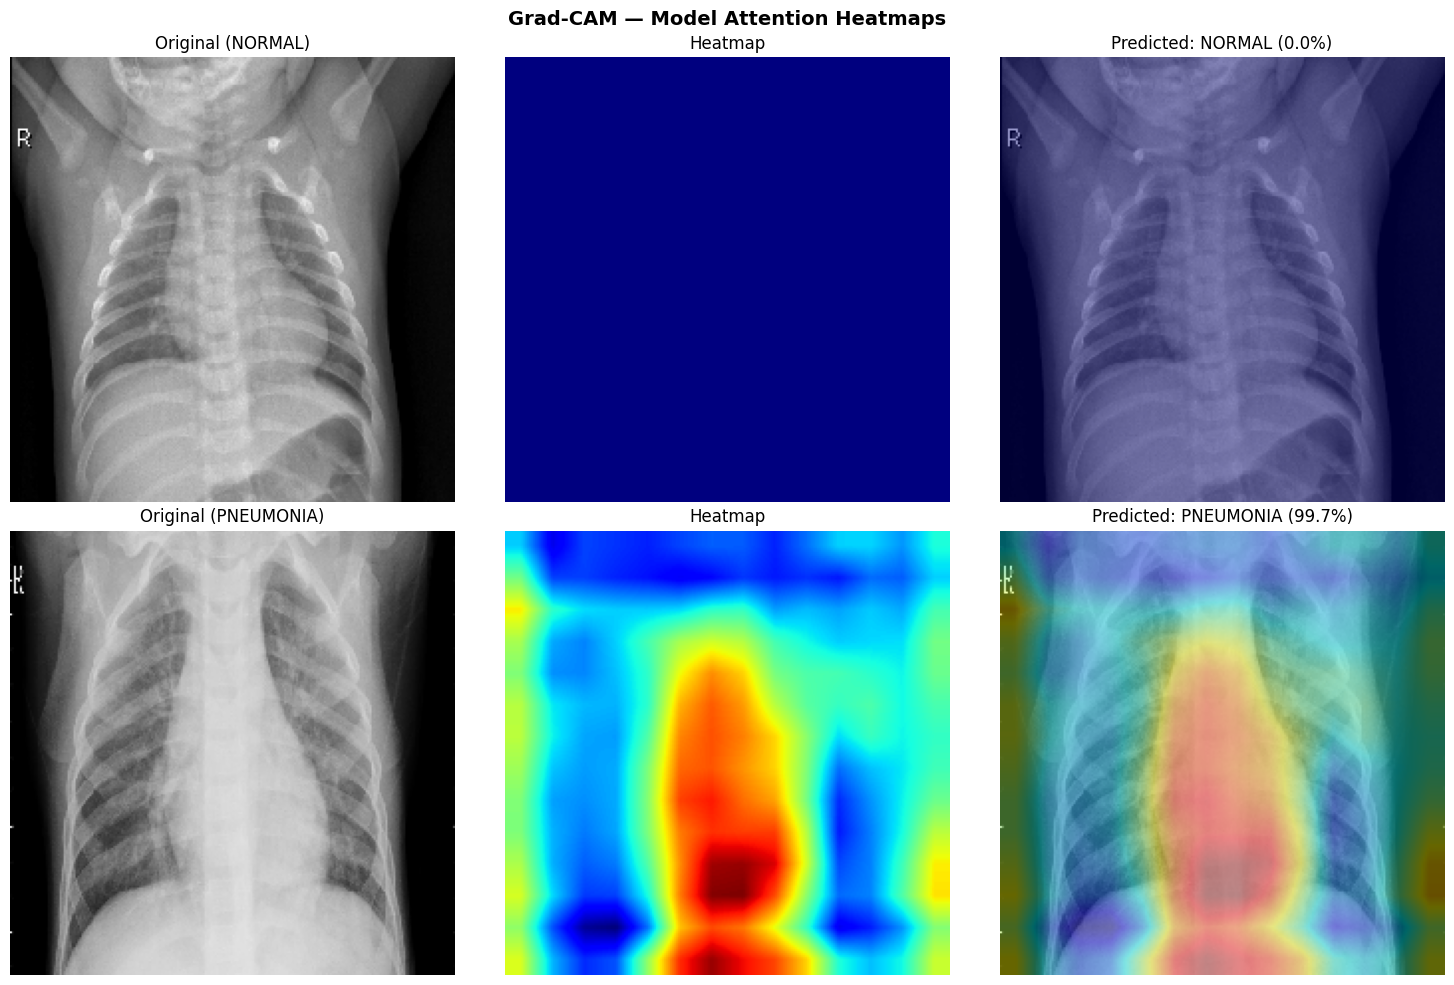

In [29]:
# =============================================================
# CELL 14 — GRAD-CAM VISUALISATION (explainability)
# =============================================================

import cv2
from tensorflow.keras.models import Model
import tensorflow as tf

def get_gradcam_heatmap(model, img_array, last_conv_layer_name='block5_conv3'):
    vgg_submodel = model.get_layer('vgg16')

    # Build a sub-model from vgg input → last conv layer output
    conv_layer = vgg_submodel.get_layer(last_conv_layer_name)

    # Full model: from vgg input all the way to final prediction
    full_grad_model = Model(
        inputs=vgg_submodel.input,
        outputs=[conv_layer.output, vgg_submodel.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, vgg_out = full_grad_model(img_array)
        # Pass vgg output through the remaining layers manually
        x = vgg_out
        for layer in model.layers[1:]:  # skip the vgg16 layer
            x = layer(x, training=False)
        loss = x[:, 0]
        tape.watch(conv_outputs)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Pick sample images
from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Grad-CAM — Model Attention Heatmaps', fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, sample_file)

    img = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_arr, axis=0)

    heatmap = get_gradcam_heatmap(best_model, img_input)

    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    original = np.uint8(255 * img_arr)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    prob = best_model.predict(img_input, verbose=0)[0][0]
    predicted = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'

    axes[i, 0].imshow(img); axes[i, 0].set_title(f'Original ({cls})')
    axes[i, 1].imshow(heatmap_resized, cmap='jet'); axes[i, 1].set_title('Heatmap')
    axes[i, 2].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title(f'Predicted: {predicted} ({prob:.1%})')

    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=120)
plt.show()

In [30]:
# =============================================================
# CELL 15 — SAVE MODEL & METADATA
# =============================================================

# Save final model (already saved as best checkpoint above)
best_model.save('pneumonia_cnn_model.h5')

# Save metadata used in the Streamlit app
metadata = {
    'img_size'     : IMG_SIZE,
    'classes'      : CLASSES,
    'class_indices': train_gen.class_indices,  # {'NORMAL': 0, 'PNEUMONIA': 1}
    'model_name'   : 'VGG16-Transfer-Learning',
    'input_shape'  : (*IMG_SIZE, 3)
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('✅ Saved: pneumonia_cnn_model.h5')
print('✅ Saved: model_metadata.pkl')
print()
print('Copy both files to the same directory as app.py before running Streamlit.')

✅ Saved: pneumonia_cnn_model.h5
✅ Saved: model_metadata.pkl

Copy both files to the same directory as app.py before running Streamlit.
